# QServe/QQQ：W4A8 服务级量化

**对应博客篇目**：PTQ 系列第 13 篇《PTQ（13）：QServe 与 QQQ（W4A8）》（系列收束篇）

## 原理概述

W4A8 是精度—性能曲线上的部署甜点位：权重 4-bit 拿满访存红利，激活 8-bit 避开 W4A4 的精度悬崖、又恰好落进 GPU INT8 Tensor Core 的原生档位。剩下的短板只有两个——attention 对 K 离群值的极端敏感，以及大 batch／长上下文下 KV cache 的显存占比。QoQ/QServe 与 QQQ 的答案不是发明新数学，而是把系列前文的零件各取所长组装起来（「组装学」）。本 demo 用 numpy 做四组可独立复现的实验：

- **Demo A · SmoothAttention**：把逐通道缩放 $\lambda$ 从 $QK^\top$ 的 K 侧等效迁移到 Q 侧——注意力侧的特殊处理思路；
- **Demo B · LoRC 低秩补偿**：以极小的 fp16 开销部分回收 W4 量化残差，并给出「先谱诊断再决定启用」的判据；
- **Demo C · 非对称 KV4**：zero-point 平移让 int4 网格罩住带偏移通道的实际支撑集；
- **Demo D · 规格权衡**：同一层上实测 W4A16 / W4A8 / W8A8 的输出误差，配合带宽／算力的账单看甜点位从何而来。


In [1]:
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# jupyter 内核已激活 inline 后端时保持不动（图可内嵌显示）；
# 否则（纯终端/无显示环境）回退到 Agg，保证脚本化执行不报错
if "inline" not in matplotlib.get_backend().lower():
    matplotlib.use("Agg")

# 优先使用系统中文字体渲染图内标注（缺失时静默回退默认字体）
_available = {f.name for f in font_manager.fontManager.ttflist}
for _cjk in ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei",
             "Noto Sans CJK SC", "SimHei"]:
    if _cjk in _available:
        plt.rcParams["font.sans-serif"] = [_cjk] + plt.rcParams["font.sans-serif"]
        break

# 固定随机种子，确保结果可复现（与 run.py 及博客正文一致）
SEED = 0
rng = np.random.default_rng(SEED)

t0 = time.time()
print(f"随机种子 SEED={SEED}，numpy {np.__version__}")


随机种子 SEED=0，numpy 2.1.1


## 第一步：构造 toy 数据

这步在做什么：合成三类真实张量的离群形态——K 的「大均值＋小波动」离群通道、线性层的权重与激活、V cache 中少数通道的稳定偏移；所有矩阵控制在 512×512 以内，CPU 秒级可跑。三个场景分别对应 QoQ/QServe 要解决的三件事：attention 分数被 K 离群值污染（→SmoothAttention）、W4 权重量化的残差（→LoRC）、KV cache 低比特化（→非对称 KV4）。


In [2]:
T, d = 512, 128                  # token 数与 head 维度

# ── 场景一：attention 的 Q / K（K 含离群通道：大均值 + 小波动）──
Q = rng.normal(0, 1.0, (T, d))
K = rng.normal(0, 1.0, (T, d))
oc = rng.choice(d, 6, replace=False)                # 离群通道索引
for j in oc:
    K[:, j] = rng.uniform(20, 40) + 0.5 * rng.normal(0, 1, T)

# ── 场景二：线性层的权重 W 与激活 X（用于 W4 量化与低秩补偿）──
M = N = 256
W = rng.normal(0, 0.02, (M, N))
X = rng.normal(0, 1.0, (T, N))
Y_ref = X @ W.T                                     # 全精度参考输出

# ── 场景三：V cache（少数通道带稳定正偏移）──
Vc = rng.normal(0, 1.0, (T, d))
occ = rng.choice(d, 10, replace=False)              # 偏移通道索引
for j in occ:
    Vc[:, j] = rng.uniform(6, 14) + rng.normal(0, 0.8, T)

print(f"Q/K: {Q.shape}，K 的离群通道 = {oc.tolist()}")
print(f"W/X: {W.shape} / {X.shape}，参考输出 Y_ref: {Y_ref.shape}")
print(f"V  : {Vc.shape}，偏移通道 = {occ.tolist()}")


Q/K: (512, 128)，K 的离群通道 = [25, 49, 70, 65, 124, 22]
W/X: (256, 256) / (512, 256)，参考输出 Y_ref: (512, 256)
V  : (512, 128)，偏移通道 = [101, 92, 46, 67, 85, 33, 87, 118, 8, 119]


## 第二步：量化工具函数

这步在做什么：实现后面所有实验共用的三件量化构件——对称 per-tensor、对称逐列、非对称逐列（带 zero-point），外加统一的相对误差度量 $\lVert a-b\rVert_F/\lVert b\rVert_F$。


In [3]:
def sym_quant(A, bits):
    """对称 per-tensor 量化：整张量共享一个步长"""
    s = np.abs(A).max() / (2 ** (bits - 1) - 1)
    return np.round(A / s) * s


def sym_quant_cols(A, bits):
    """对称逐列量化：每列（通道）一个步长"""
    out = np.empty_like(A)
    for j in range(A.shape[1]):
        out[:, j] = sym_quant(A[:, j], bits)
    return out


def asym_quant_cols(A, bits):
    """逐列非对称量化：zero-point 平移 + 均匀网格（等价于内置 shift）"""
    lo, hi = A.min(0), A.max(0)
    zp = (lo + hi) / 2
    s = np.where(hi > lo, (hi - lo) / (2 ** bits - 1), 1.0)
    return zp + s * np.round((A - zp) / s)


def rel_err(a, b):
    """相对 Frobenius 误差 ||a-b||_F / ||b||_F"""
    return float(np.linalg.norm(a - b) / np.linalg.norm(b))


print("工具函数就绪：sym_quant / sym_quant_cols / asym_quant_cols / rel_err")


工具函数就绪：sym_quant / sym_quant_cols / asym_quant_cols / rel_err


## 第三步（Demo A）：SmoothAttention——注意力侧的特殊处理

这步在做什么：直接对含离群通道的 K 做 per-tensor int8 时，离群均值会在 $S=QK^\top/\sqrt{d}$ 的内积里逐 token 累积、污染 softmax 的输入；SmoothAttention 利用恒等式把逐通道缩放从 K 侧免费迁到 Q 侧：

$$S=\frac{\bigl(Q\,\mathrm{diag}(\lambda)\bigr)\bigl(K\,\mathrm{diag}(1/\lambda)\bigr)^{\top}}{\sqrt{d}},\qquad \lambda_j=\max\lvert K_{:,j}\rvert^{\alpha},\ \ \alpha\in(0,1)$$

浮点意义下两条路径严格相等，但平滑后的 K 削掉了离群峰、量化噪声骤降。「平滑/缩放/迁移」类方法共享这一个恒等式模板，差别只在把它套在哪个乘法、哪一侧——AWQ 保护权重的重要输入通道，SmoothAttention 保护分数的重要贡献通道。


In [4]:
alpha = 0.6                                        # 平滑指数（原系统在校准中学出）

# 参考分数与直接量化路径
S_ref   = (Q @ K.T) / np.sqrt(d)
S_naive = (Q @ sym_quant(K, 8).T) / np.sqrt(d)     # 直接对 K 做 per-tensor int8

# SmoothAttention 路径：λ 迁到 Q 一侧，只对削峰后的 K 量化
lam      = np.abs(K).max(0) ** alpha
K_s, Q_s = K / lam, Q * lam
S_smooth = (Q_s @ sym_quant(K_s, 8).T) / np.sqrt(d)

e_naive  = rel_err(S_naive, S_ref)
e_smooth = rel_err(S_smooth, S_ref)
print("[Demo A] attention 分数矩阵的重构相对误差（K 侧 per-tensor int8）")
print(f"  直接量化 K      : {e_naive:.4f}")
print(f"  SmoothAttention : {e_smooth:.4f}"
      f"   （降低 {(1 - e_smooth / e_naive) * 100:.1f}%）")
print(f"\nK 的通道 absmax 峰值：{np.abs(K).max(0).max():.1f} "
      f"-> {np.abs(K_s).max(0).max():.1f}（λ 已迁入 Q 侧，浮点意义下严格等价）")


[Demo A] attention 分数矩阵的重构相对误差（K 侧 per-tensor int8）
  直接量化 K      : 0.0133
  SmoothAttention : 0.0040   （降低 70.2%）

K 的通道 absmax 峰值：38.2 -> 4.3（λ 已迁入 Q 侧，浮点意义下严格等价）


## 第四步（Demo B）：LoRC 低秩补偿——先做谱诊断

这步在做什么：RTN-W4 的残差 $\Delta W=W-\hat W$ 可用一份 rank-$r$ 的 fp16 低秩修正部分回收（$\tilde W=\hat W+U_r\Sigma_r V_r^\top$），存储开销仅 $r(M+N)/(MN)$；但收益取决于残差的**谱集中度**——舍入噪声谱接近平坦时，低秩杠杆无处发力。这正是 LoRC 类方法在文献中「时好时坏」的原因：它不是稳定的增益项，而是对残差结构的杠杆押注。


In [5]:
Wq    = np.stack([sym_quant(W[i], 4) for i in range(M)])   # RTN per-channel W4
delta = W - Wq                                             # 量化残差

e_w4 = rel_err(X @ Wq.T, Y_ref)

# 谱诊断：top-r 奇异值能量占比越低，低秩可压缩性越差
sv = np.linalg.svd(delta, compute_uv=False)
energy_top8 = float((sv[:8] ** 2).sum() / (sv ** 2).sum())
print(f"[Demo B] W4(RTN) 层输出相对误差 = {e_w4:.4f}")
print(f"  残差 top-8 奇异值能量占比 = {energy_top8:.2f}"
      f"（接近 0 则谱平坦，补偿收益有限）")

U, s_v, Vt = np.linalg.svd(delta, full_matrices=False)
lorc_err = {}
for r in [4, 8, 16]:
    corr = U[:, :r] @ np.diag(s_v[:r]) @ Vt[:r]            # rank-r fp16 修正
    overhead = r * (M + N) / (M * N) * 100                 # 相对权重量的参数占比
    lorc_err[r] = rel_err(X @ (Wq + corr).T, Y_ref)
    print(f"  rank-{r:<2d} 补偿后 : {lorc_err[r]:.4f}"
          f"   （存储开销 {overhead:.2f}%，"
          f"误差降低 {(1 - lorc_err[r] / e_w4) * 100:.1f}%）")


[Demo B] W4(RTN) 层输出相对误差 = 0.1260
  残差 top-8 奇异值能量占比 = 0.12（接近 0 则谱平坦，补偿收益有限）


  rank-4  补偿后 : 0.1220   （存储开销 3.12%，误差降低 3.2%）
  rank-8  补偿后 : 0.1185   （存储开销 6.25%，误差降低 6.0%）
  rank-16 补偿后 : 0.1115   （存储开销 12.50%，误差降低 11.5%）


## 第五步（Demo C）：KV cache 的非对称 int4

这步在做什么：KV 分布中少数通道带稳定偏移，对称 int4 的 15 级网格以零为中心、一半刻度浪费在不存在的负半轴；带 zero-point 的非对称网格直接罩住实际支撑集——这是第 10 篇 OS+「shift」思想在 KV 上的免费重演，代价只是每组多存一个 zero-point、反量化时多一次乘加。


In [6]:
v_sym  = sym_quant_cols(Vc, 4)                     # 逐通道对称 int4
v_asym = asym_quant_cols(Vc, 4)                    # 逐通道非对称 int4
e_sym, e_asym = rel_err(v_sym, Vc), rel_err(v_asym, Vc)

print("[Demo C] KV cache（V）的 4-bit 重建相对误差")
print(f"  逐通道对称   int4 : {e_sym:.4f}")
print(f"  逐通道非对称 int4 : {e_asym:.4f}"
      f"   （降低 {(1 - e_asym / e_sym) * 100:.1f}%）")

# 归因诊断：偏移通道在对称方案平方误差中的占比
err_ch = np.linalg.norm(v_sym - Vc, axis=0) ** 2
shift_mask = np.zeros(d, dtype=bool)
shift_mask[occ] = True
share = err_ch[shift_mask].sum() / err_ch.sum()
print(f"\n偏移通道仅占 {shift_mask.mean() * 100:.0f}% 的列数，"
      f"却贡献了对称方案平方误差的 {share * 100:.1f}% —— 非对称 zero-point 正是对症下药")


[Demo C] KV cache（V）的 4-bit 重建相对误差
  逐通道对称   int4 : 0.0644
  逐通道非对称 int4 : 0.0400   （降低 37.9%）

偏移通道仅占 8% 的列数，却贡献了对称方案平方误差的 52.6% —— 非对称 zero-point 正是对症下药


## 第六步（Demo D）：W4A16 vs W4A8 vs W8A8 的权衡

这步在做什么：在同一线性层上只改位宽组合、实测输出相对误差，再配上理论账单，看清「甜点位」是怎么来的。

| 规格 | 权重带宽 | 计算路径 | 直觉预期 |
|:---|:---|:---|:---|
| W4A16 | fp16 基线的 25% | 反量化后走 fp16 GEMM | 精度≈W4 地板，计算受限于反量化/fp16 吞吐 |
| W4A8 | fp16 基线的 25% | INT8 Tensor Core | 精度≈W4 地板＋微量 A8 噪声 |
| W8A8 | fp16 基线的 50% | INT8 Tensor Core | 最准，权重带宽翻倍 |

若实测中 W4A8 与 W4A16 几乎重合，则说明：**W4 决定误差主导项，A8 几乎白送精度却换来原生翻倍算力**——这正是 QServe/QQQ 选择 W4A8 的全部动机。


In [7]:
def w_quant(W_, bits):
    """权重按行（输出通道）对称量化"""
    return np.stack([sym_quant(W_[i], bits) for i in range(W_.shape[0])])

specs = [("W8A8",  8, 8),
         ("W4A8",  4, 8),
         ("W4A16", 4, None)]                        # None 表示激活留在 fp16

spec_err = {}
print("[Demo D] 同一线性层 X @ W.T 在三种规格下的输出相对误差")
for name, w_bits, a_bits in specs:
    W_hat = w_quant(W, w_bits)
    X_hat = sym_quant(X, a_bits) if a_bits else X
    spec_err[name] = rel_err(X_hat @ W_hat.T, Y_ref)
    bw = "fp16 基线的 25%" if w_bits == 4 else "fp16 基线的 50%"
    print(f"  {name:<6s}: 误差 {spec_err[name]:.4f}   （权重带宽为 {bw}）")

print(f"\n解读：W4A8（{spec_err['W4A8']:.4f}）与 W4A16（{spec_err['W4A16']:.4f}）几乎重合"
      f"——误差由 W4 主导，A8 只引入微量噪声；"
      f"W8A8（{spec_err['W8A8']:.4f}）最准，但要为权重带宽付双倍价钱。")


[Demo D] 同一线性层 X @ W.T 在三种规格下的输出相对误差
  W8A8  : 误差 0.0121   （权重带宽为 fp16 基线的 50%）
  W4A8  : 误差 0.1264   （权重带宽为 fp16 基线的 25%）
  W4A16 : 误差 0.1260   （权重带宽为 fp16 基线的 25%）

解读：W4A8（0.1264）与 W4A16（0.1260）几乎重合——误差由 W4 主导，A8 只引入微量噪声；W8A8（0.0121）最准，但要为权重带宽付双倍价钱。


## 第七步：可视化汇总

这步在做什么：把四个 demo 的关键证据画进一张 2×2 图——K 的削峰效果、残差奇异值谱、KV 逐列误差归因，以及全部规格的误差总览。


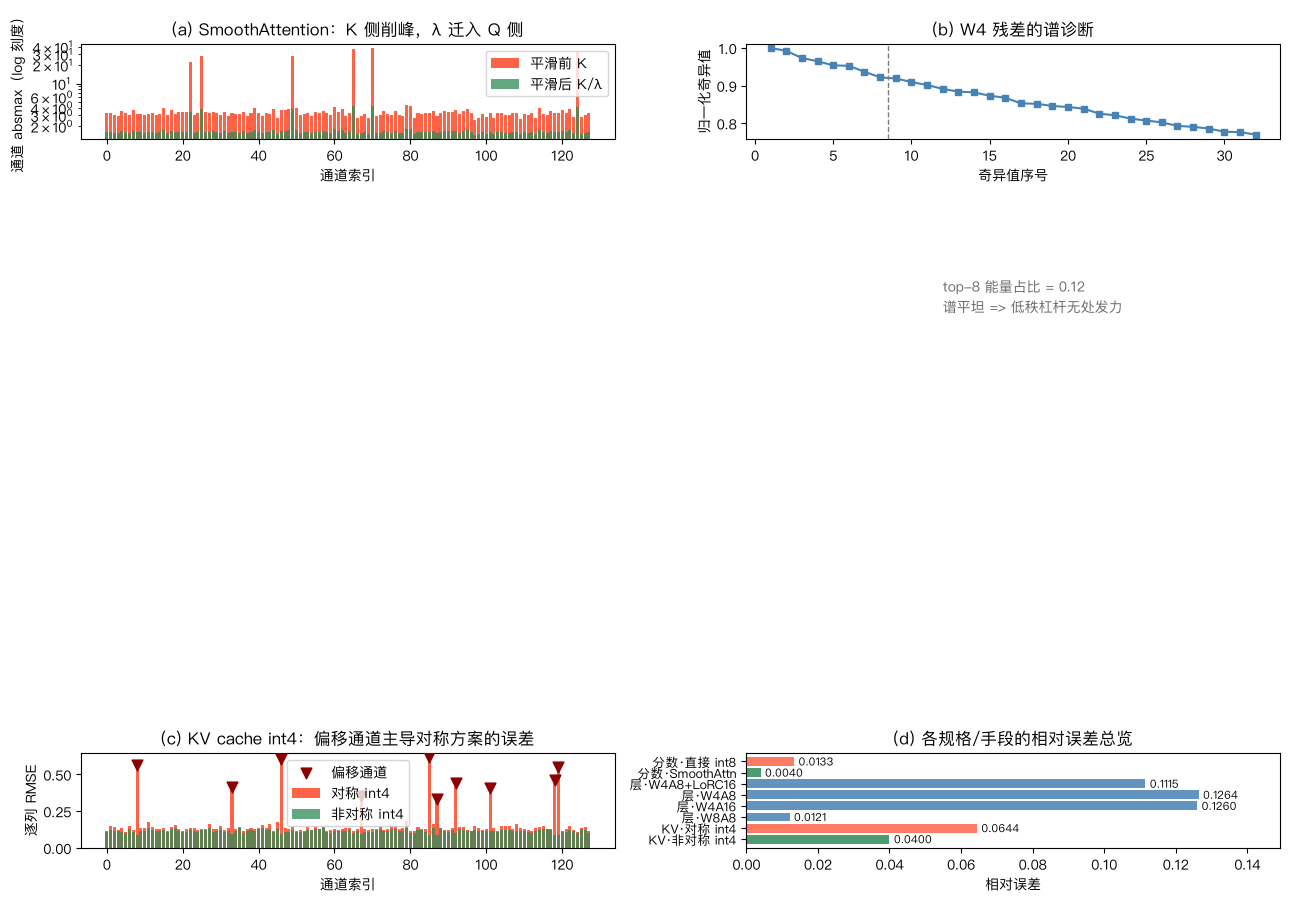

全部 cell 总耗时 1.06s


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
idx = np.arange(d)

# ── (a) SmoothAttention：K 通道 absmax 平滑前后 ──
ax = axes[0, 0]
ax.bar(idx, np.abs(K).max(0), color="tomato", label="平滑前 K")
ax.bar(idx, np.abs(K_s).max(0), color="seagreen", alpha=0.75, label="平滑后 K/λ")
ax.set_yscale("log")
ax.set_xlabel("通道索引")
ax.set_ylabel("通道 absmax（log 刻度）")
ax.set_title("(a) SmoothAttention：K 侧削峰，λ 迁入 Q 侧")
ax.legend()

# ── (b) LoRC：残差奇异值谱 ──
ax = axes[0, 1]
ax.plot(np.arange(1, 33), sv[:32] / sv[0], "s-", ms=4, color="steelblue")
ax.axvline(8.5, color="gray", ls="--", lw=1)
ax.text(12, 0.30, f"top-8 能量占比 = {energy_top8:.2f}\n谱平坦 => 低秩杠杆无处发力",
        fontsize=10, color="dimgray")
ax.set_xlabel("奇异值序号")
ax.set_ylabel("归一化奇异值")
ax.set_title("(b) W4 残差的谱诊断")

# ── (c) KV4：逐列 RMSE，偏移通道是元凶 ──
ax = axes[1, 0]
rmse_sym  = np.sqrt(((v_sym  - Vc) ** 2).mean(axis=0))
rmse_asym = np.sqrt(((v_asym - Vc) ** 2).mean(axis=0))
ax.bar(idx, rmse_sym, color="tomato", label="对称 int4")
ax.bar(idx, rmse_asym, color="seagreen", alpha=0.75, label="非对称 int4")
ax.scatter(occ, rmse_sym[occ], color="darkred", marker="v", s=60,
           zorder=3, label="偏移通道")
ax.set_xlabel("通道索引")
ax.set_ylabel("逐列 RMSE")
ax.set_title("(c) KV cache int4：偏移通道主导对称方案的误差")
ax.legend()

# ── (d) 全部规格误差总览 ──
ax = axes[1, 1]
entries = [
    ("分数·直接 int8",  e_naive,          "tomato"),
    ("分数·SmoothAttn", e_smooth,         "seagreen"),
    ("层·W4A8+LoRC16",  lorc_err[16],     "steelblue"),
    ("层·W4A8",         spec_err["W4A8"], "steelblue"),
    ("层·W4A16",        spec_err["W4A16"], "steelblue"),
    ("层·W8A8",         spec_err["W8A8"], "steelblue"),
    ("KV·对称 int4",    e_sym,            "tomato"),
    ("KV·非对称 int4",  e_asym,           "seagreen"),
]
labels = [t[0] for t in entries]
vals   = [t[1] for t in entries]
colors = [t[2] for t in entries]
y = np.arange(len(entries))
ax.barh(y, vals, color=colors, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
for yi, v in zip(y, vals):
    ax.text(v + max(vals) * 0.01, yi, f"{v:.4f}", va="center", fontsize=8)
ax.set_xlabel("相对误差")
ax.set_xlim(0, max(vals) * 1.18)
ax.set_title("(d) 各规格/手段的相对误差总览")

plt.tight_layout()
plt.show()

print(f"全部 cell 总耗时 {time.time() - t0:.2f}s")


## 结果解读与方法局限

### 关键数字汇总（SEED=0 实测；规模较 run.py 缩至 ≤512×512，结论同量级）

| 实验 | 对照 | 实测 | 解读 |
|:---|:---|:---|:---|
| Demo A · SmoothAttention | 直接量化 K：0.0133 | 平滑后 **0.0040**（-70.2%） | K 的 absmax 峰值从 38.2 削到 4.3，等效迁移几乎免费地救回七成误差 |
| Demo B · LoRC | W4 输出误差 0.1260 | rank-16 后 0.1115（-11.5%，开销 12.5%） | top-8 能量占比仅 0.12，谱平坦 ⇒ 单层收益个位数起步，启用前应先做谱诊断 |
| Demo C · 非对称 KV4 | 对称 int4：0.0644 | 非对称 **0.0400**（-37.9%） | 8% 的偏移通道贡献了对称方案 52.6% 的平方误差，zero-point 正是对症下药 |
| Demo D · 规格权衡 | W4A16：0.1260 | W4A8 **0.1264**（几乎重合）；W8A8 0.0121 | W4 决定误差主导项，A8 白送的精度换来 INT8 Tensor Core 原生算力 |

三条 takeaway：

1. **甜点位的逻辑被完整复现**：W4A8 与 W4A16 的误差差距只有 0.0004，却把激活计算搬进了 INT8 Tensor Core——精度上近乎免费，系统上翻倍算力，这就是 QServe 敢以 W4A8KV4 为核心规格的底气；
2. **注意力侧必须特殊处理**：同样的 int8，K 侧不加处理误差是 0.0133，一次 SmoothAttention 迁移降到 0.0040——softmax 所在的位置对 logit 误差不宽容，值得单独开小灶；
3. **KV4 的收益来自分布形状而非比特数本身**：非对称 zero-point 只是挪了网格中心，就拿下近四成误差改善，印证「shift 是离群通道自身的救赎」。

### 方法局限

1. **教学简化**：α 固定取 0.6 且未迁入 RoPE 的旋转矩阵（原系统迁入）；LoRC 基线用 RTN（GPTQ 基线下残差更小、补偿收益比例相近）；KV 偏移幅度做了教学化夸张；
2. **只兑现了算法侧**：QServe 真正的杀手锏——计算感知权重重排、寄存器级反量化、服务级调度——都是 kernel／系统工程，numpy 里只能验证误差、无法兑现吞吐，「INT8 吞吐约 2 倍」是论文口径而非本 demo 实测；
3. **静态校准假设**：λ 与 zero-point 都来自固定的合成分布；真实 KV 分布随上下文长度与内容漂移，静态 per-channel 参数在超长上下文下的稳健性公开证据仍然有限；
4. **规模与耦合失真**：toy 矩阵没有真实 LLM 的层间方差差异，全家桶零件（GPTQ、旋转、重排）互相改变工作分布的耦合贡献，在本 demo 的单层视角中不可见。
